# Custom Factor Trajectory Localization

This notebook shows how to use `gtsam.CustomFactor` inside a small `Pose2` trajectory problem.

Each custom factor:

- touches one pose in the trajectory
- stores that pose's landmark measurements
- stacks all landmark residuals into one vector
- fills the analytical Jacobian using `Pose2.transformTo`

We then combine those custom factors with standard odometry `BetweenFactorPose2` factors so the graph is a connected trajectory.

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/CustomFactorLocalizationExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [10]:
import matplotlib.pyplot as plt
import numpy as np

import gtsam
from gtsam.symbol_shorthand import X

np.set_printoptions(precision=3, suppress=True)

## 1. Landmarks and Noise Models

We use the same known landmarks for every pose. To make the plot more interesting, the landmark measurements are fairly noisy, while odometry stays reasonably accurate.

In [11]:
LANDMARKS = [
    np.array([5.0, 0.0]),
    np.array([2.0, 3.0]),
    np.array([6.0, 4.0]),
    np.array([8.0, 1.0]),
]

LANDMARK_SIGMA = 0.25
ODOMETRY_SIGMA_XY = 0.15
ODOMETRY_SIGMA_THETA = 0.08

LANDMARK_NOISE_MODEL = gtsam.noiseModel.Isotropic.Sigma(2 * len(LANDMARKS), LANDMARK_SIGMA)
ODOMETRY_NOISE_MODEL = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([ODOMETRY_SIGMA_XY, ODOMETRY_SIGMA_XY, ODOMETRY_SIGMA_THETA])
)

print("Landmarks:")
for i, landmark in enumerate(LANDMARKS):
    print(f"  L{i}: {landmark}")

Landmarks:
  L0: [5. 0.]
  L1: [2. 3.]
  L2: [6. 4.]
  L3: [8. 1.]


## 2. Custom Residual Object

The residual object is itself the callback passed into `CustomFactor`. This keeps the example compact while still using analytical Jacobians.

The important trick in Python is to allocate Jacobian arrays in Fortran order before passing them into `Pose2.transformTo`.

In [12]:
class LandmarkLocalizationResidual:
    """Stack landmark errors for a single Pose2 variable."""

    def __init__(self, measurements: list[np.ndarray]):
        self.measurements = measurements

    def __call__(
        self,
        this: gtsam.CustomFactor,
        values: gtsam.Values,
        jacobians: list[np.ndarray] | None,
    ) -> np.ndarray:
        pose = values.atPose2(this.keys()[0])
        residual = np.zeros(2 * len(self.measurements))

        if jacobians is not None:
            jacobians[0] = np.zeros((2 * len(self.measurements), 3), order="F")

        for i, (landmark, measurement) in enumerate(zip(LANDMARKS, self.measurements)):
            if jacobians is not None:
                H_pose = np.zeros((2, 3), order="F")
                H_point = np.zeros((2, 2), order="F")
                predicted = pose.transformTo(landmark, H_pose, H_point)
                jacobians[0][2 * i : 2 * i + 2, :] = H_pose
            else:
                predicted = pose.transformTo(landmark)

            residual[2 * i : 2 * i + 2] = predicted - measurement

        return residual

## 3. Create a Noisy Trajectory Problem

In [13]:
rng = np.random.default_rng(7)


def measure_landmarks(pose: gtsam.Pose2) -> list[np.ndarray]:
    return [pose.transformTo(landmark) + rng.normal(0.0, LANDMARK_SIGMA, size=2) for landmark in LANDMARKS]


true_poses = [
    gtsam.Pose2(1.0, 2.0, 0.3),
    gtsam.Pose2(2.5, 1.0, -0.2),
    gtsam.Pose2(3.0, 2.8, 0.4),
    gtsam.Pose2(4.4, 1.6, -0.1),
]

keys = [X(i) for i in range(len(true_poses))]
measurements = [measure_landmarks(pose) for pose in true_poses]
odometry_measurements = [
    true_poses[i].between(true_poses[i + 1]).retract(
        rng.normal(0.0, [ODOMETRY_SIGMA_XY, ODOMETRY_SIGMA_XY, ODOMETRY_SIGMA_THETA])
    )
    for i in range(len(true_poses) - 1)
]

print("Landmark measurements at pose 0:")
for measurement in measurements[0]:
    print(" ", measurement)

Landmark measurements at pose 0:
  [ 3.23061308 -3.01806742]
  [1.18232223 0.43716832]
  [5.25405516 0.18516031]
  [ 6.40687112 -2.68892412]


## 4. Inspect One Custom Factor

At the ground truth, the residual is not zero anymore because we injected noise into the landmark measurements. Still, we can linearize the factor and inspect the Jacobian generated by the callback.

In [14]:
factor = gtsam.CustomFactor(LANDMARK_NOISE_MODEL, [keys[0]], LandmarkLocalizationResidual(measurements[0]))

values = gtsam.Values()
values.insert(keys[0], true_poses[0])

linear = factor.linearize(values)
A, b = linear.jacobian()

print("Nonlinear error:", factor.error(values))
print("Jacobian shape:", A.shape)
A

Nonlinear error: 1.9737191833686931
Jacobian shape: (8, 3)


array([[ -4.        ,   0.        , -12.37101522],
       [  0.        ,  -4.        , -12.92122217],
       [ -4.        ,   0.        ,   2.63926513],
       [  0.        ,  -4.        ,  -5.00342678],
       [ -4.        ,   0.        ,   1.73228778],
       [  0.        ,  -4.        , -21.47089144],
       [ -4.        ,   0.        , -12.09591174],
       [  0.        ,  -4.        , -25.56734087]])

## 5. Solve the Trajectory

Each pose gets one landmark `CustomFactor`, and consecutive poses are connected with odometry `BetweenFactorPose2` factors.

In [15]:
graph = gtsam.NonlinearFactorGraph()

for key, measurement_set in zip(keys, measurements):
    graph.add(gtsam.CustomFactor(LANDMARK_NOISE_MODEL, [key], LandmarkLocalizationResidual(measurement_set)))

for key1, key2, odometry in zip(keys[:-1], keys[1:], odometry_measurements):
    graph.add(gtsam.BetweenFactorPose2(key1, key2, odometry, ODOMETRY_NOISE_MODEL))

initial = gtsam.Values()
for key, pose in zip(keys, true_poses):
    initial.insert(key, pose.retract(np.array([0.8, -0.6, 0.25])))

result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()

for i, (key, true_pose) in enumerate(zip(keys, true_poses)):
    print(f"True pose {i}:      {true_pose}")
    print(f"Estimated pose {i}: {result.atPose2(key)}")
    print()

True pose 0:      (1, 2, 0.3)

Estimated pose 0: (1.14111, 2.30025, 0.237817)


True pose 1:      (2.5, 1, -0.2)

Estimated pose 1: (2.53991, 1.15384, -0.231066)


True pose 2:      (3, 2.8, 0.4)

Estimated pose 2: (3.21574, 2.96852, 0.396358)


True pose 3:      (4.4, 1.6, -0.1)

Estimated pose 3: (4.59661, 1.6944, -0.112688)




## 6. Plot Ground Truth and Optimized Trajectories

The landmark measurements are noisy enough that the optimized trajectory does not sit exactly on top of ground truth, which makes the comparison easier to see.

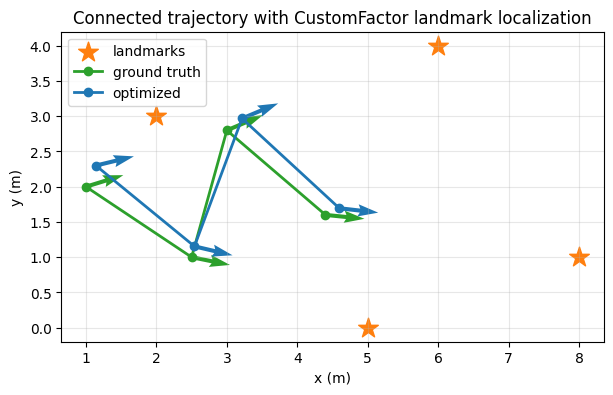

In [16]:
def draw_pose(ax, pose: gtsam.Pose2, color: str) -> None:
    x, y, theta = pose.x(), pose.y(), pose.theta()
    ax.quiver(
        [x],
        [y],
        [np.cos(theta)],
        [np.sin(theta)],
        angles="xy",
        scale_units="xy",
        scale=1.8,
        color=color,
    )


fig, ax = plt.subplots(figsize=(7, 6))
landmarks_array = np.array(LANDMARKS)
true_xy = np.array([[pose.x(), pose.y()] for pose in true_poses])
result_xy = np.array([[result.atPose2(key).x(), result.atPose2(key).y()] for key in keys])

ax.scatter(
    landmarks_array[:, 0],
    landmarks_array[:, 1],
    marker="*",
    s=220,
    color="tab:orange",
    label="landmarks",
)

ax.plot(true_xy[:, 0], true_xy[:, 1], "-o", color="tab:green", linewidth=2, label="ground truth")
ax.plot(result_xy[:, 0], result_xy[:, 1], "-o", color="tab:blue", linewidth=2, label="optimized")

for pose in true_poses:
    draw_pose(ax, pose, "tab:green")

for key in keys:
    draw_pose(ax, result.atPose2(key), "tab:blue")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Connected trajectory with CustomFactor landmark localization")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
plt.show()

## Takeaways

- `CustomFactor` works well when you already know the residual you want to write.
- A small callable object is often the cleanest way to package measurements and constants.
- In Python, `Pose2.transformTo` can now provide analytical Jacobians directly when you pass Fortran-order output arrays.
- Custom factors combine naturally with standard GTSAM factors such as `BetweenFactorPose2` in the same trajectory graph.